# 03_Fast_Modeling_Local.ipynb

## Part 1: Setup and Modular Integration
This notebook implements the **Leakage-Free Modeling Pipeline**. It uses modular functions from `src` to ensure that:
1. **Scalar Leakage** is prevented by centering on train folds only.
2. **Topology Leakage** is prevented by re-discovering the network structure within each fold.
3. **Predictive Performance** is measured via 5-fold cross-validation.

In [19]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import ast
from sklearn.metrics import mean_squared_error, r2_score

# Add parent directory to path for imports
sys.path.append(os.path.abspath('..'))

from src.modeling import run_bulletproof_cv, prepare_raw_modeling_data, get_network_interactions, CORE_ASPECTS
from src.network_builder import build_and_analyze_network

# 1. Load Local Data
data_path = '../data/Seminar_Amazon_Results_FULL.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Local data loaded: {len(df)} rows.")
    
    # Parse stringified lists of tuples if they are strings
    if isinstance(df['aspect_sentiments'].iloc[0], str):
        print("Parsing aspect_sentiments column...")
        df['aspect_sentiments'] = df['aspect_sentiments'].apply(ast.literal_eval)
else:
    print(f"❌ Error: File not found at {data_path}. Please ensure the CSV is in the './data/' folder.")

✅ Local data loaded: 701528 rows.
Parsing aspect_sentiments column...


## Part 2: Leakage-Free Performance Evaluation
We use `run_bulletproof_cv` to compare the Baseline Model (Additive) with the Network-Informed Model (Interactions).

In [20]:
print("Running Bulletproof Cross-Validation (Leakage-Free)...")
(rmse_base, adj_r2_base), (rmse_net, adj_r2_net) = run_bulletproof_cv(df)

print("\n" + "="*60)
print("CROSS-VALIDATED RESULTS (No Leakage)")
print("="*60)
print(f"Baseline (Additive) -> Avg RMSE: {rmse_base:.4f} | Avg Adj R2: {adj_r2_base:.4f}")
print(f"Network (Interactions) -> Avg RMSE: {rmse_net:.4f} | Avg Adj R2: {adj_r2_net:.4f}")
print("="*60)

2026-05-31 23:25:28,934 - INFO - Pivoting raw sentiment features...


Running Bulletproof Cross-Validation (Leakage-Free)...


2026-05-31 23:25:29,953 - INFO - Sparsity Filter: Dropped 379395 empty reviews. Remaining valid reviews: 322133
2026-05-31 23:25:29,953 - INFO - Starting Bulletproof Cross-Validation (Leakage-Free)...
2026-05-31 23:25:29,967 - INFO - Processing Fold 1/5...
2026-05-31 23:25:30,085 - INFO - Standardizing feature matrix for 7 active aspects (N=257706)...
2026-05-31 23:25:30,117 - INFO - Starting EBIC selection over 100 lambda values (gamma=0.5)...
2026-05-31 23:25:30,250 - INFO - Selected lambda: 0.001000
2026-05-31 23:25:30,250 - INFO - Generating interaction features from 11 network edges...
2026-05-31 23:25:30,268 - INFO - Generating interaction features from 11 network edges...
2026-05-31 23:25:30,385 - INFO - Processing Fold 2/5...
2026-05-31 23:25:30,518 - INFO - Standardizing feature matrix for 7 active aspects (N=257706)...
2026-05-31 23:25:30,566 - INFO - Starting EBIC selection over 100 lambda values (gamma=0.5)...
2026-05-31 23:25:30,706 - INFO - Selected lambda: 0.001000
2026-


CROSS-VALIDATED RESULTS (No Leakage)
Baseline (Additive) -> Avg RMSE: 1.2144 | Avg Adj R2: 0.3351
Network (Interactions) -> Avg RMSE: 1.2035 | Avg Adj R2: 0.3469


## Part 3: Full-Dataset Fit and Diagnostic Plots
For visualization and interpretability (AIC/BIC), we fit the models on the entire dataset. This allows us to inspect coefficients and interaction weights.

In [21]:
# 1. Prepare modeling data (Centering on full dataset for final fit)
raw_modeling_data = prepare_raw_modeling_data(df)
full_data = raw_modeling_data.copy()

# Center Features
for col in CORE_ASPECTS:
    full_data[f"{col}_centered"] = full_data[col] - full_data[col].mean()

# 2. Discovery Network topology for full dataset
network_results = build_and_analyze_network(df)
G = network_results['graph']

# 3. Create Interactions
full_data, interaction_cols = get_network_interactions(full_data, G)

base_centered_cols = [f"{col}_centered" for col in CORE_ASPECTS]
y = full_data['rating']

# Fit Baseline Model
X1 = sm.add_constant(full_data[base_centered_cols])
model_baseline = sm.OLS(y, X1).fit()

# Fit Network Model
X2 = sm.add_constant(full_data[base_centered_cols + interaction_cols])
model_network = sm.OLS(y, X2).fit()

def get_metrics(model, X, y_true):
    y_pred = model.predict(X)
    y_clipped = np.clip(y_pred, 1, 5)
    
    # Original
    rmse_orig = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_orig = r2_score(y_true, y_pred)
    
    # Clipped
    rmse_clip = np.sqrt(mean_squared_error(y_true, y_clipped))
    r2_clip = r2_score(y_true, y_clipped)
    
    n = len(y_true)
    p = len(model.params) - 1
    adj_r2_orig = 1 - (1 - r2_orig) * (n - 1) / (n - p - 1)
    adj_r2_clip = 1 - (1 - r2_clip) * (n - 1) / (n - p - 1)
    
    return {
        'RMSE_Orig': rmse_orig, 'AdjR2_Orig': adj_r2_orig,
        'RMSE_Clip': rmse_clip, 'AdjR2_Clip': adj_r2_clip
    }

m_base = get_metrics(model_baseline, X1, y)
m_net = get_metrics(model_network, X2, y)

print("\n" + "="*85)
print(f"{'Model Variant':<28} | {'RMSE':<10} | {'Adj R2':<10} | {'BIC':<12}")
print("-" * 85)
print(f"{'Baseline (Original)':<28} | {m_base['RMSE_Orig']:<10.4f} | {m_base['AdjR2_Orig']:<10.4f} | {model_baseline.bic:<12.1f}")
print(f"{'Baseline (Clipped 1-5)':<28} | {m_base['RMSE_Clip']:<10.4f} | {m_base['AdjR2_Clip']:<10.4f} | {'N/A':<12}")
print(f"{'Network (Original)':<28} | {m_net['RMSE_Orig']:<10.4f} | {m_net['AdjR2_Orig']:<10.4f} | {model_network.bic:<12.1f}")
print(f"{'Network (Clipped 1-5)':<28} | {m_net['RMSE_Clip']:<10.4f} | {m_net['AdjR2_Clip']:<10.4f} | {'N/A':<12}")
print("="*85)

2026-05-31 23:25:32,867 - INFO - Pivoting raw sentiment features...
2026-05-31 23:25:33,923 - INFO - Sparsity Filter: Dropped 379395 empty reviews. Remaining valid reviews: 322133
2026-05-31 23:25:35,225 - INFO - Standardizing feature matrix for 7 active aspects (N=701528)...
2026-05-31 23:25:35,403 - INFO - Starting EBIC selection over 100 lambda values (gamma=0.5)...
2026-05-31 23:25:35,554 - INFO - Selected lambda: 0.001000
2026-05-31 23:25:35,571 - INFO - Generating interaction features from 15 network edges...



Model Variant                | RMSE       | Adj R2     | BIC         
-------------------------------------------------------------------------------------
Baseline (Original)          | 1.2143     | 0.3353     | 1039391.3   
Baseline (Clipped 1-5)       | 1.1985     | 0.3525     | N/A         
Network (Original)           | 1.2011     | 0.3496     | 1032536.3   
Network (Clipped 1-5)        | 1.1945     | 0.3567     | N/A         


### Diagnostic Visualizations

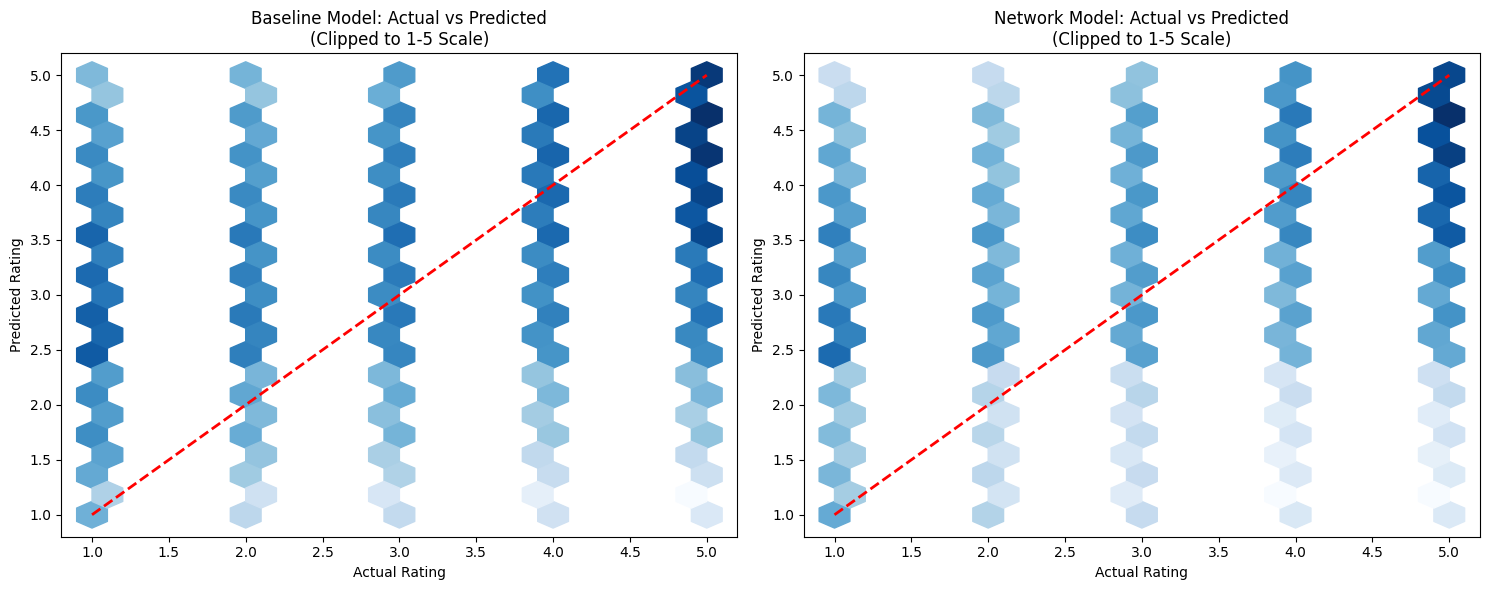

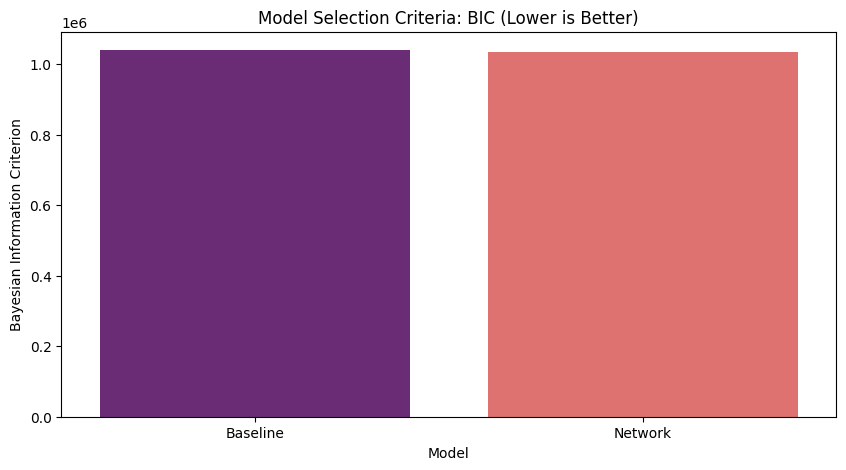

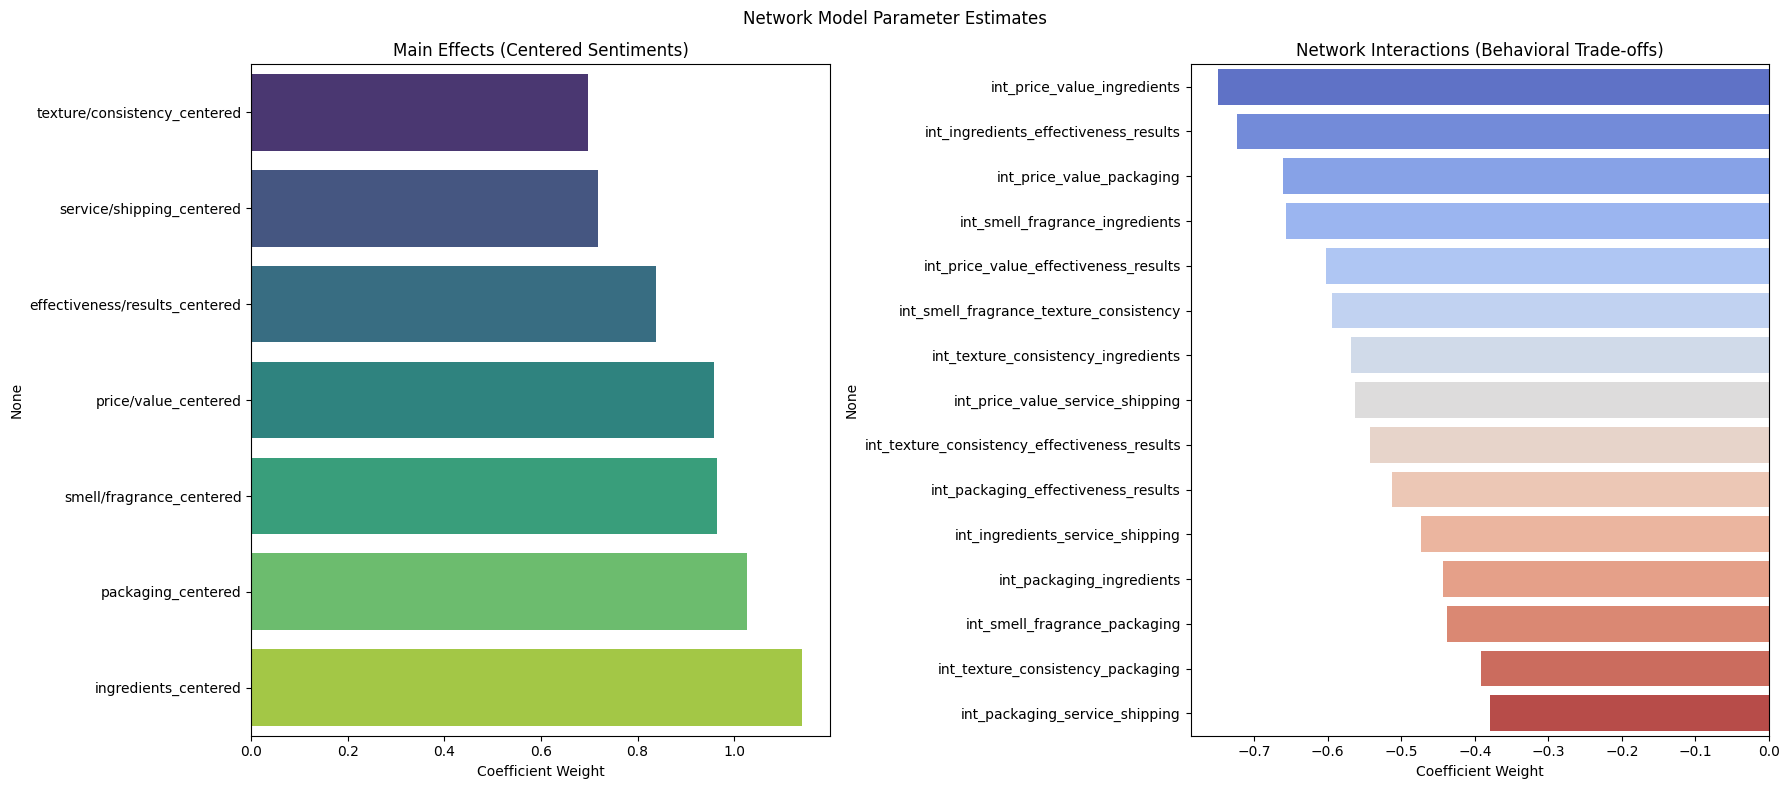

In [22]:
# 1. Actual vs Predicted (Hexbin)
plt.figure(figsize=(15, 6))
models_list = [('Baseline', model_baseline, X1), ('Network', model_network, X2)]

for i, (name, model, X) in enumerate(models_list):
    y_pred = np.clip(model.predict(X), 1, 5)
    plt.subplot(1, 2, i+1)
    plt.hexbin(y, y_pred, gridsize=20, cmap='Blues', bins='log')
    plt.plot([1, 5], [1, 5], '--r', lw=2)
    plt.title(f'{name} Model: Actual vs Predicted\n(Clipped to 1-5 Scale)')
    plt.xlabel('Actual Rating')
    plt.ylabel('Predicted Rating')
plt.tight_layout()
plt.show()

# 2. Model Complexity Comparison (BIC)
bic_df = pd.DataFrame({
    'Model': ['Baseline', 'Network'],
    'BIC': [model_baseline.bic, model_network.bic]
}) 

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='BIC', data=bic_df, palette='magma', hue='Model', legend=False)
plt.title('Model Selection Criteria: BIC (Lower is Better)')
plt.ylabel('Bayesian Information Criterion')
plt.show()

# 3. Coefficients Analysis (Network Model)
coef_df = model_network.params.drop('const').sort_values()
interactions = coef_df[coef_df.index.str.startswith('int_')]
main_effects = coef_df[~coef_df.index.str.startswith('int_')]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x=main_effects.values, y=main_effects.index, palette='viridis', hue=main_effects.index, legend=False, ax=axes[0])
axes[0].set_title('Main Effects (Centered Sentiments)')
axes[0].set_xlabel('Coefficient Weight')

if not interactions.empty:
    sns.barplot(x=interactions.values, y=interactions.index, palette='coolwarm', hue=interactions.index, legend=False, ax=axes[1])
    axes[1].set_title('Network Interactions (Behavioral Trade-offs)')
    axes[1].set_xlabel('Coefficient Weight')
else:
    axes[1].text(0.5, 0.5, 'No Significant Interactions Found', ha='center', va='center')

plt.suptitle('Network Model Parameter Estimates')
plt.tight_layout()
plt.show()